In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 3

# Linear Regression Model

---

### Objectives

- Load Clean Dataset
- Feature Selection
- Train Linear Regression
- Evaluate Performance
- Predict Sales
- Save Model

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [4]:
# ==============================================================================
# LOAD CLEAN DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
# ==============================================================================
# DATASET SHAPE
# ==============================================================================

print(df.shape)

(8601, 33)


In [6]:
# ==============================================================================
# FIRST FIVE RECORDS
# ==============================================================================

df.head()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,2023-01-01,41,1029,2,0,0,0,2,32.1,107.07,287.06,3.78,452,111.98,102.88,14,278,27,2023,1,1,52,1,3,4,1,3,1.620072,9.10,15.6772,96.3028,0.096774,0
1,2023-01-02,46,1167,5,3,0,1,0,18.3,114.77,271.06,4.44,452,713.49,664.33,48,192,54,2023,1,2,1,1,1,4,0,3,2.341969,49.16,342.4752,371.0148,0.279793,48
2,2023-01-03,7,1024,3,1,1,1,0,17.9,81.74,235.13,4.12,964,788.14,796.34,40,336,146,2023,1,3,1,1,5,4,0,3,2.860534,-8.20,315.2560,472.8840,0.433234,40
3,2023-01-04,13,1181,2,1,0,1,2,35.7,114.66,225.62,7.08,874,761.42,741.65,13,363,135,2023,1,4,1,1,6,4,0,3,2.401099,19.77,98.9846,662.4354,0.370879,13
4,2023-01-05,18,1180,5,1,0,0,2,23.9,90.80,291.05,9.19,244,1385.00,1479.97,49,48,0,2023,1,5,1,1,4,4,0,3,4.979592,-94.97,678.6500,706.3500,0.000000,0


In [7]:
# ==============================================================================
# DATA INFORMATION
# ==============================================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8601 entries, 0 to 8600
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    8601 non-null   str    
 1   Store_ID                8601 non-null   int64  
 2   Product_ID              8601 non-null   int64  
 3   Category                8601 non-null   int64  
 4   Region                  8601 non-null   int64  
 5   Holiday                 8601 non-null   int64  
 6   Promotion               8601 non-null   int64  
 7   Weather                 8601 non-null   int64  
 8   Temperature             8601 non-null   float64
 9   Fuel_Price              8601 non-null   float64
 10  CPI                     8601 non-null   float64
 11  Unemployment            8601 non-null   float64
 12  Inventory               8601 non-null   int64  
 13  Price                   8601 non-null   float64
 14  Competitor_Price        8601 non-null   float64
 15

In [8]:
# ==============================================================================
# CHECK MISSING VALUES
# ==============================================================================

df.isnull().sum()

Date                      0
Store_ID                  0
Product_ID                0
Category                  0
Region                    0
Holiday                   0
Promotion                 0
Weather                   0
Temperature               0
Fuel_Price                0
CPI                       0
Unemployment              0
Inventory                 0
Price                     0
Competitor_Price          0
Discount                  0
Customers                 0
Sales                     0
Year                      0
Month                     0
Day                       0
Week                      0
Quarter                   0
Day_Name                  0
Month_Name                0
Weekend                   0
Season                    0
Inventory_Per_Customer    0
Price_Difference          0
Discount_Amount           0
Final_Price               0
Sales_Per_Customer        0
Promotion_Impact          0
dtype: int64

In [9]:
# ==============================================================================
# DEFINE TARGET VARIABLE
# ==============================================================================

TARGET = "Sales"

print("Target Variable :", TARGET)

Target Variable : Sales


In [11]:
# ==============================================================================
# INPUT FEATURES
# ==============================================================================

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [12]:
# ==============================================================================
# REMOVE DATETIME COLUMN IF PRESENT
# ==============================================================================

if "Date" in X.columns:
    X = X.drop(columns=["Date"])

In [13]:
# ==============================================================================
# CHECK DATA TYPES
# ==============================================================================

X.dtypes

Store_ID                    int64
Product_ID                  int64
Category                    int64
Region                      int64
Holiday                     int64
Promotion                   int64
Weather                     int64
Temperature               float64
Fuel_Price                float64
CPI                       float64
Unemployment              float64
Inventory                   int64
Price                     float64
Competitor_Price          float64
Discount                    int64
Customers                   int64
Year                        int64
Month                       int64
Day                         int64
Week                        int64
Quarter                     int64
Day_Name                    int64
Month_Name                  int64
Weekend                     int64
Season                      int64
Inventory_Per_Customer    float64
Price_Difference          float64
Discount_Amount           float64
Final_Price               float64
Sales_Per_Cust

In [14]:
# ==============================================================================
# ENCODE REMAINING CATEGORICAL COLUMNS
# ==============================================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = encoder.fit_transform(X[col])

In [15]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Train Shape :",X_train.shape)

print("Test Shape :",X_test.shape)

Train Shape : (6880, 31)
Test Shape : (1721, 31)


In [16]:
# ==============================================================================
# STANDARD SCALER
# ==============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [17]:
# ==============================================================================
# CREATE LINEAR REGRESSION MODEL
# ==============================================================================

model = LinearRegression()

In [18]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

model.fit(

    X_train,

    y_train

)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [19]:
# ==============================================================================
# MODEL COEFFICIENTS
# ==============================================================================

coefficients = pd.DataFrame({

"Feature":X.columns,

"Coefficient":model.coef_

})

coefficients

,Feature,Coefficient
0,Store_ID,-0.001815
1,Product_ID,-0.329298
2,Category,-0.155693
3,Region,0.264424
4,Holiday,3.574374
5,Promotion,15.796565
6,Weather,0.133229
7,Temperature,0.052609
8,Fuel_Price,-0.040991
9,CPI,-0.012269


In [20]:
# ==============================================================================
# MODEL INTERCEPT
# ==============================================================================

print("Intercept :",model.intercept_)

Intercept : 75.6738372093023


In [21]:
# ==============================================================================
# PREDICT ON TRAIN DATA
# ==============================================================================

y_train_pred = model.predict(X_train)

print("Training Prediction Completed")

Training Prediction Completed


In [22]:
# ==============================================================================
# PREDICT ON TEST DATA
# ==============================================================================

y_test_pred = model.predict(X_test)

print("Testing Prediction Completed")

Testing Prediction Completed


In [35]:
# ==============================================================================
# TRAINING MAE
# ==============================================================================

train_mae = mean_absolute_error(y_train, y_train_pred)

print("Training MAE :", train_mae)
print("test_mae" in globals())
print("test_mse" in globals())
print("test_rmse" in globals())
print("test_r2" in globals())
print("adjusted_r2" in globals())
print("mape" in globals())

Training MAE : 14.001415891119812
False
True
True
True
True
True


In [24]:
# ==============================================================================
# TRAINING MSE
# ==============================================================================

train_mse = mean_squared_error(y_train, y_train_pred)

print("Training MSE :", train_mse)

Training MSE : 289.10729190399496


In [25]:
# ==============================================================================
# TESTING MSE
# ==============================================================================

test_mse = mean_squared_error(y_test, y_test_pred)

print("Testing MSE :", test_mse)

Testing MSE : 285.7601283045731


In [26]:
# ==============================================================================
# TRAINING RMSE
# ==============================================================================

train_rmse = np.sqrt(train_mse)

print("Training RMSE :", train_rmse)

Training RMSE : 17.003155351404484


In [27]:
# ==============================================================================
# TESTING RMSE
# ==============================================================================

test_rmse = np.sqrt(test_mse)

print("Testing RMSE :", test_rmse)

Testing RMSE : 16.90444108228879


In [28]:
# ==============================================================================
# TRAINING R2 SCORE
# ==============================================================================

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² :", train_r2)

Training R² : 0.9040183175566948


In [29]:
# ==============================================================================
# TESTING R2 SCORE
# ==============================================================================

test_r2 = r2_score(y_test, y_test_pred)

print("Testing R² :", test_r2)

Testing R² : 0.8995986369317001


In [30]:
# ==============================================================================
# ADJUSTED R2 SCORE
# ==============================================================================

n = X_test.shape[0]

p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Adjusted R² :", adjusted_r2)

Adjusted R² : 0.8977558647261836


In [31]:
# ==============================================================================
# MEAN ABSOLUTE PERCENTAGE ERROR
# ==============================================================================

mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("MAPE :", mape)

MAPE : inf


In [37]:
print(y_test.shape)
print(y_test_pred.shape)

(1721,)
(1721,)


In [40]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

performance = pd.DataFrame({

"Metric":[
"MAE",
"MSE",
"RMSE",
"R2 Score",
"Adjusted R2",
"MAPE"
],

"Value":[
test_mae,
test_mse,
test_rmse,
test_r2,
adjusted_r2,
mape
]

})

performance

,Metric,Value
0,MAE,13.807808
1,MSE,285.760128
2,RMSE,16.904441
3,R2 Score,0.899599
4,Adjusted R2,0.897756
5,MAPE,inf


In [41]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

results = pd.DataFrame({

"Actual":y_test,

"Predicted":y_test_pred

})

results.head(20)

,Actual,Predicted
5839,6,-14.375289
4275,91,96.037133
6086,49,51.778330
8265,90,94.662110
5493,15,28.834415
1688,127,118.583880
5241,59,58.933197
221,53,66.211977
239,63,75.569460
2208,53,82.512646


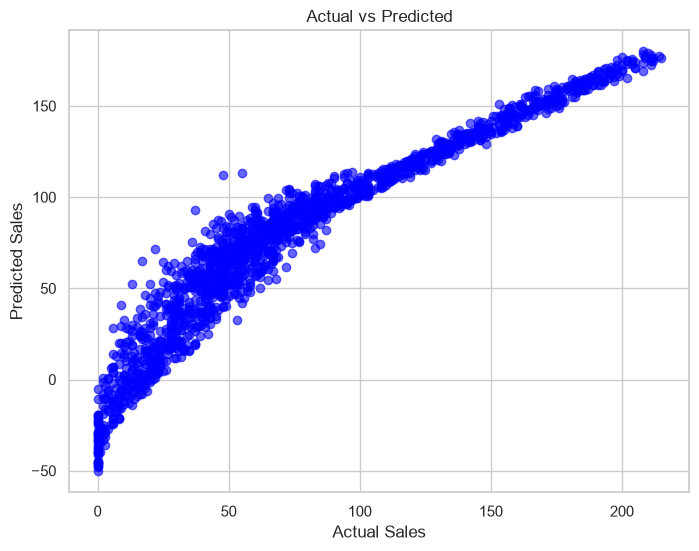

In [42]:
# ==============================================================================
# ACTUAL VS PREDICTED SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6,
    color="blue"
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()

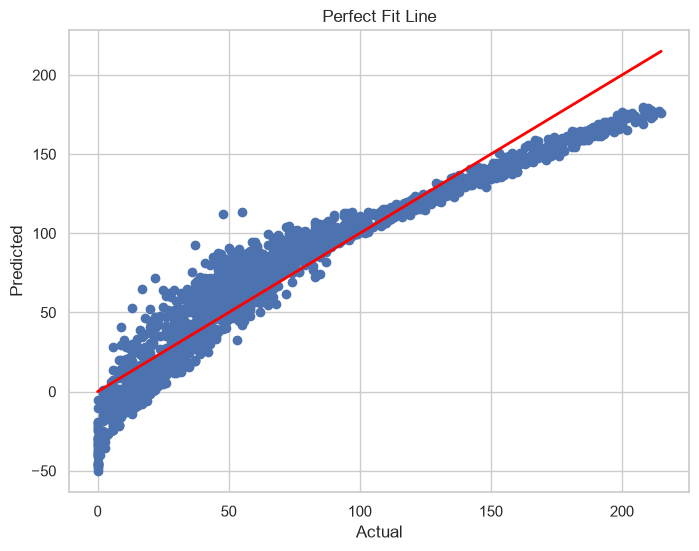

In [43]:
# ==============================================================================
# PERFECT FIT LINE
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Perfect Fit Line")

plt.show()

In [44]:
# ==============================================================================
# RESIDUALS
# ==============================================================================

residuals = y_test - y_test_pred

residuals.head()

5839    20.375289
4275    -5.037133
6086    -2.778330
8265    -4.662110
5493   -13.834415
Name: Sales, dtype: float64

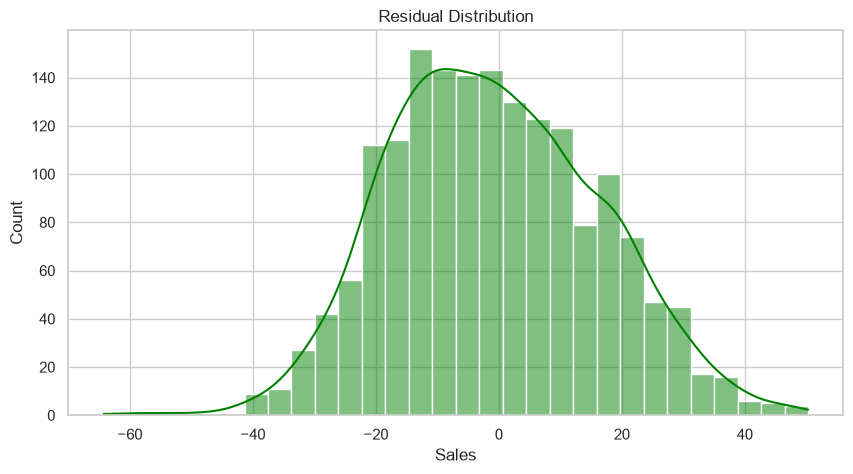

In [45]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True,
    bins=30,
    color="green"
)

plt.title("Residual Distribution")

plt.show()

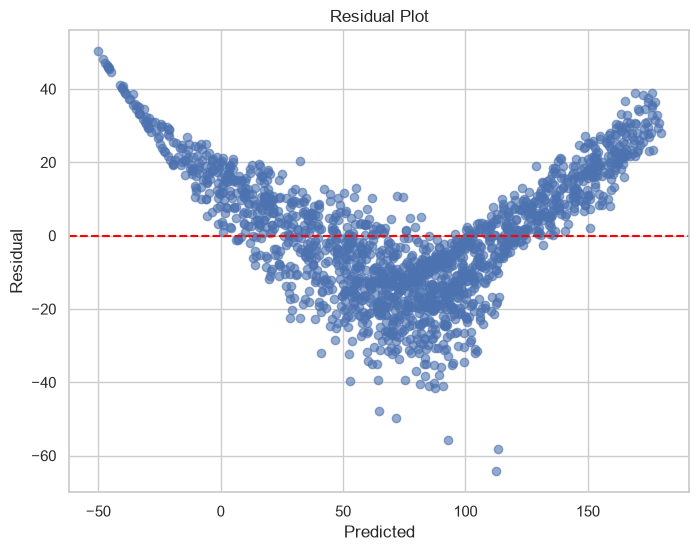

In [46]:
# ==============================================================================
# RESIDUAL SCATTER PLOT
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [47]:
# ==============================================================================
# PERFORMANCE REPORT
# ==============================================================================

print("="*60)

print("LINEAR REGRESSION PERFORMANCE")

print("="*60)

print("MAE           :", round(test_mae,2))
print("MSE           :", round(test_mse,2))
print("RMSE          :", round(test_rmse,2))
print("R2 Score      :", round(test_r2,4))
print("Adjusted R2   :", round(adjusted_r2,4))
print("MAPE          :", round(mape,2),"%")

print("="*60)

LINEAR REGRESSION PERFORMANCE
MAE           : 13.81
MSE           : 285.76
RMSE          : 16.9
R2 Score      : 0.8996
Adjusted R2   : 0.8978
MAPE          : inf %


In [48]:
# ==============================================================================
# CROSS VALIDATION
# ==============================================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores")

print(cv_scores)

Cross Validation Scores
[0.90321106 0.90304534 0.9038874  0.89943738 0.90210737]


In [49]:
# ==============================================================================
# AVERAGE CROSS VALIDATION SCORE
# ==============================================================================

print("Average CV Score :", cv_scores.mean())

Average CV Score : 0.9023377101429201


In [50]:
# ==============================================================================
# FEATURE COEFFICIENTS
# ==============================================================================

coef_df = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_

})

coef_df.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)

coef_df.head(15)

,Feature,Coefficient
15,Customers,35.510765
29,Sales_Per_Customer,21.149065
5,Promotion,15.796565
4,Holiday,3.574374
25,Inventory_Per_Customer,1.057732
17,Month,0.949338
30,Promotion_Impact,0.598075
22,Month_Name,0.374674
3,Region,0.264424
26,Price_Difference,0.215809


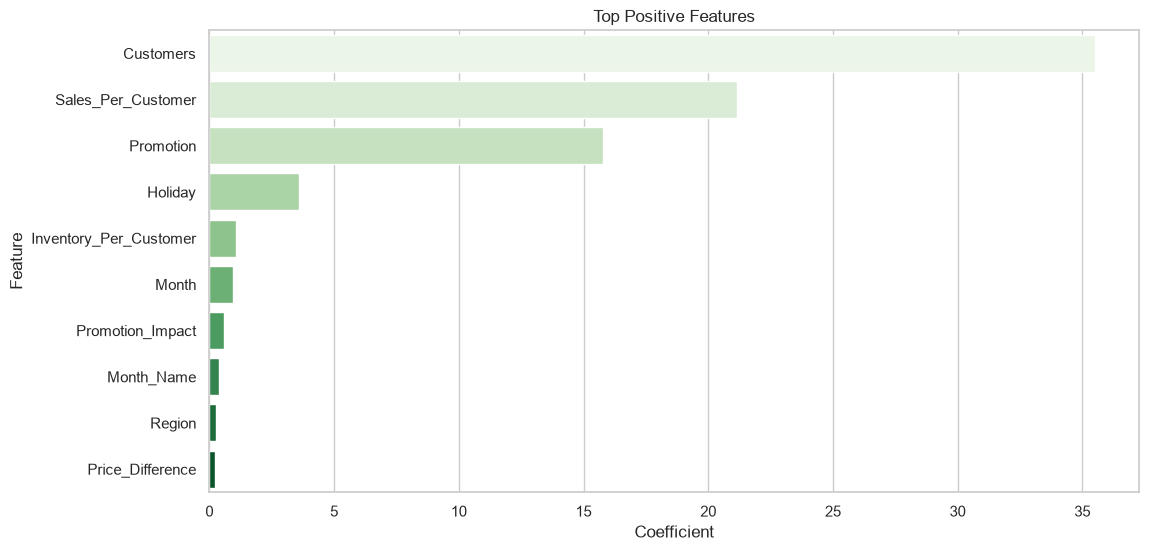

In [51]:
# ==============================================================================
# TOP POSITIVE FEATURES
# ==============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=coef_df.head(10),
    x="Coefficient",
    y="Feature",
    palette="Greens"
)

plt.title("Top Positive Features")

plt.show()

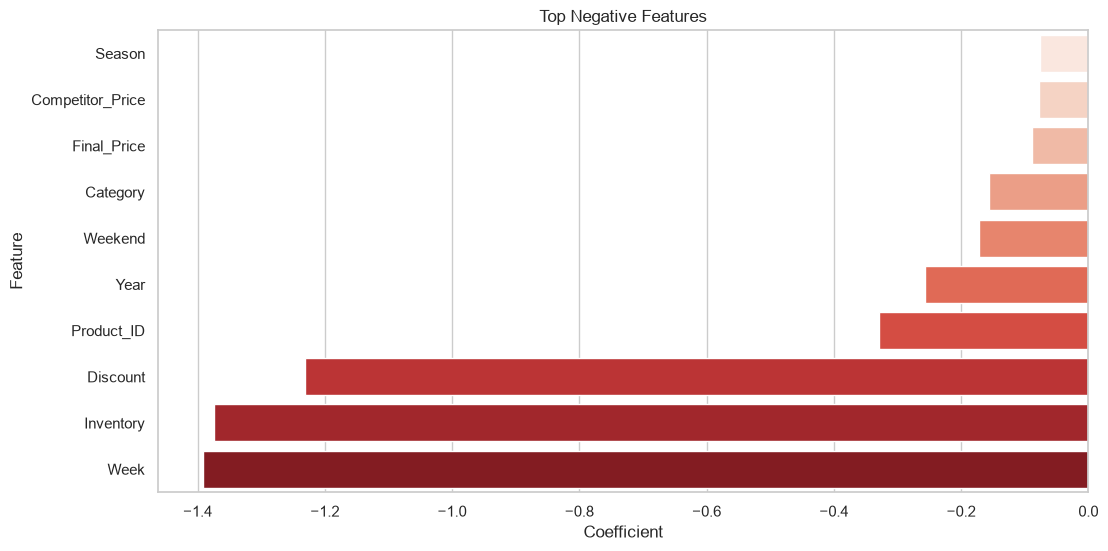

In [52]:
# ==============================================================================
# TOP NEGATIVE FEATURES
# ==============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=coef_df.tail(10),
    x="Coefficient",
    y="Feature",
    palette="Reds"
)

plt.title("Top Negative Features")

plt.show()

In [53]:
# ==============================================================================
# PREDICTION TABLE
# ==============================================================================

prediction_df = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_test_pred,

    "Error": y_test.values - y_test_pred

})

prediction_df.head(20)

,Actual,Predicted,Error
0,6,-14.375289,20.375289
1,91,96.037133,-5.037133
2,49,51.778330,-2.778330
3,90,94.662110,-4.662110
4,15,28.834415,-13.834415
5,127,118.583880,8.416120
6,59,58.933197,0.066803
7,53,66.211977,-13.211977
8,63,75.569460,-12.569460
9,53,82.512646,-29.512646


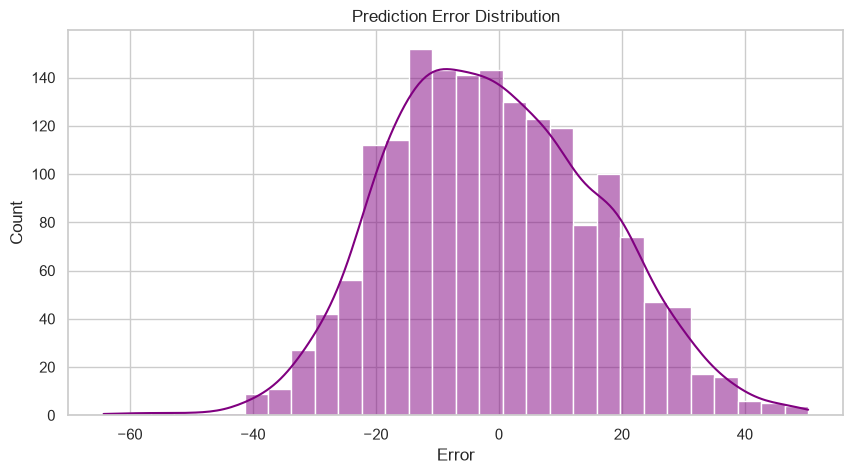

In [54]:
# ==============================================================================
# ERROR DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    prediction_df["Error"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Prediction Error Distribution")

plt.show()

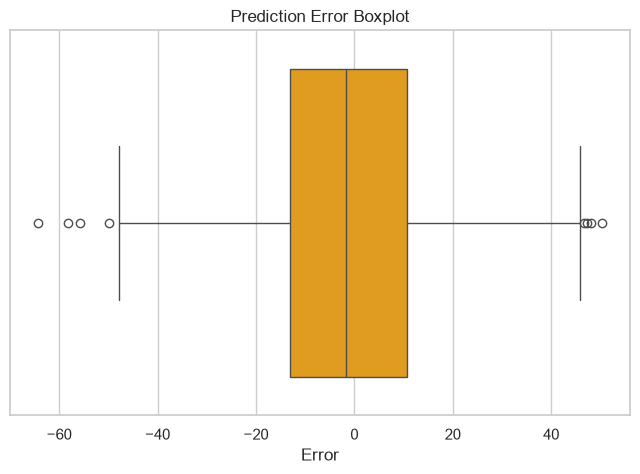

In [55]:
# ==============================================================================
# ERROR BOXPLOT
# ==============================================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=prediction_df["Error"],
    color="orange"
)

plt.title("Prediction Error Boxplot")

plt.show()

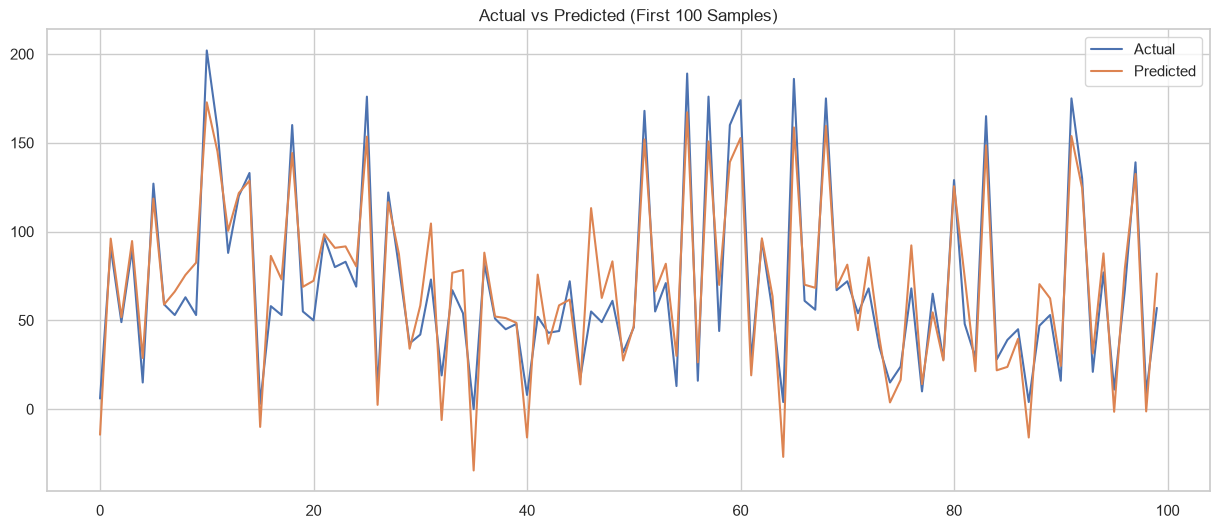

In [56]:
# ==============================================================================
# ACTUAL VS PREDICTED LINE CHART
# ==============================================================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    y_test_pred[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted (First 100 Samples)")

plt.show()

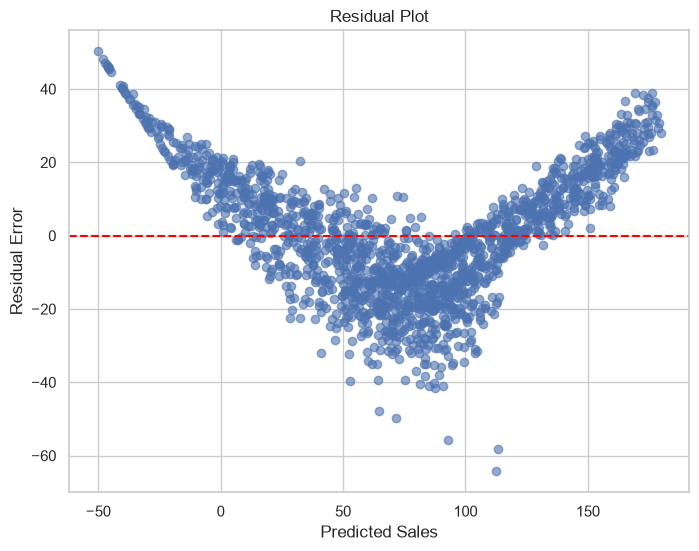

In [57]:
# ==============================================================================
# RESIDUAL SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    prediction_df["Error"],
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Predicted Sales")

plt.ylabel("Residual Error")

plt.show()

In [58]:
# ==============================================================================
# SAVE LINEAR REGRESSION MODEL
# ==============================================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    model,
    "model/linear_regression.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [59]:
# ==============================================================================
# SAVE SCALER
# ==============================================================================

joblib.dump(
    scaler,
    "model/linear_scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [61]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

import os

# Create dataset folder if it doesn't exist
os.makedirs("dataset", exist_ok=True)

prediction_df.to_csv(
    os.path.join("dataset", "linear_regression_predictions.csv"),
    index=False
)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


In [62]:
# ==============================================================================
# VERIFY MODEL FOLDER
# ==============================================================================

import os

print(os.listdir("model"))

['label_encoder.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'scaler.pkl']


In [63]:
# ==============================================================================
# VERIFY DATASET FOLDER
# ==============================================================================

print(os.listdir("dataset"))

['linear_regression_predictions.csv']


In [64]:
# ==============================================================================
# BUSINESS INTERPRETATION
# ==============================================================================

print("Business Interpretation")

print("- Linear Regression establishes a baseline forecasting model.")
print("- Lower MAE and RMSE indicate better prediction accuracy.")
print("- R² shows how well the model explains sales variation.")

Business Interpretation
- Linear Regression establishes a baseline forecasting model.
- Lower MAE and RMSE indicate better prediction accuracy.
- R² shows how well the model explains sales variation.


In [65]:
# ==============================================================================
# PERFORMANCE SUMMARY TABLE
# ==============================================================================

summary = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Adjusted R2",
        "MAPE"
    ],

    "Value":[
        test_mae,
        test_mse,
        test_rmse,
        test_r2,
        adjusted_r2,
        mape
    ]

})

summary

,Metric,Value
0,MAE,13.807808
1,MSE,285.760128
2,RMSE,16.904441
3,R2,0.899599
4,Adjusted R2,0.897756
5,MAPE,inf


In [66]:
# ==============================================================================
# EXPORT PERFORMANCE
# ==============================================================================

summary.to_csv(
    "dataset/Linear_Regression_Performance.csv",
    index=False
)

print("Performance Report Saved")

Performance Report Saved


In [67]:
# ==============================================================================
# MODEL SUMMARY
# ==============================================================================

print("="*60)

print("LINEAR REGRESSION MODEL SUMMARY")

print("="*60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Features Used    :", X.shape[1])

print("="*60)

LINEAR REGRESSION MODEL SUMMARY
Training Samples : 6880
Testing Samples  : 1721
Features Used    : 31


In [68]:
# ==============================================================================
# DISPLAY BEST 10 PREDICTIONS
# ==============================================================================

prediction_df.head(10)

,Actual,Predicted,Error
0,6,-14.375289,20.375289
1,91,96.037133,-5.037133
2,49,51.778330,-2.778330
3,90,94.662110,-4.662110
4,15,28.834415,-13.834415
5,127,118.583880,8.416120
6,59,58.933197,0.066803
7,53,66.211977,-13.211977
8,63,75.569460,-12.569460
9,53,82.512646,-29.512646


In [69]:
# ==============================================================================
# DISPLAY WORST 10 PREDICTIONS
# ==============================================================================

prediction_df.sort_values(
    "Error",
    key=abs,
    ascending=False
).head(10)

,Actual,Predicted,Error
664,48,112.268013,-64.268013
46,55,113.214471,-58.214471
1052,37,92.689526,-55.689526
611,0,-50.292489,50.292489
1023,22,71.793654,-49.793654
1308,0,-48.129111,48.129111
1179,17,64.790260,-47.790260
749,0,-47.226991,47.226991
434,0,-46.640801,46.640801
1085,0,-45.953575,45.953575


In [70]:
# ==============================================================================
# MODEL SCORE
# ==============================================================================

print("Model Score :", model.score(X_test, y_test))

Model Score : 0.8995986369317001


In [71]:
# ==============================================================================
# TOTAL FEATURES
# ==============================================================================

print("Total Features :", len(X.columns))

Total Features : 31


In [72]:
# ==============================================================================
# FEATURE NAMES
# ==============================================================================

print(X.columns.tolist())

['Store_ID', 'Product_ID', 'Category', 'Region', 'Holiday', 'Promotion', 'Weather', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Inventory', 'Price', 'Competitor_Price', 'Discount', 'Customers', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'Day_Name', 'Month_Name', 'Weekend', 'Season', 'Inventory_Per_Customer', 'Price_Difference', 'Discount_Amount', 'Final_Price', 'Sales_Per_Customer', 'Promotion_Impact']


In [73]:
# ==============================================================================
# DISPLAY COEFFICIENT TABLE
# ==============================================================================

coef_df

,Feature,Coefficient
15,Customers,35.510765
29,Sales_Per_Customer,21.149065
5,Promotion,15.796565
4,Holiday,3.574374
25,Inventory_Per_Customer,1.057732
17,Month,0.949338
30,Promotion_Impact,0.598075
22,Month_Name,0.374674
3,Region,0.264424
26,Price_Difference,0.215809


In [74]:
# ==============================================================================
# TOP 10 IMPORTANT FEATURES
# ==============================================================================

coef_df.head(10)

,Feature,Coefficient
15,Customers,35.510765
29,Sales_Per_Customer,21.149065
5,Promotion,15.796565
4,Holiday,3.574374
25,Inventory_Per_Customer,1.057732
17,Month,0.949338
30,Promotion_Impact,0.598075
22,Month_Name,0.374674
3,Region,0.264424
26,Price_Difference,0.215809


In [75]:
# ==============================================================================
# BOTTOM 10 FEATURES
# ==============================================================================

coef_df.tail(10)

,Feature,Coefficient
24,Season,-0.075527
13,Competitor_Price,-0.077561
28,Final_Price,-0.087963
2,Category,-0.155693
23,Weekend,-0.172205
16,Year,-0.256094
1,Product_ID,-0.329298
14,Discount,-1.231856
11,Inventory,-1.374206
19,Week,-1.392013


In [76]:
# ==============================================================================
# FINAL CONCLUSION
# ==============================================================================

print("Linear Regression model successfully trained and evaluated.")
print("Results will be compared with Decision Tree, Random Forest,")
print("XGBoost, LightGBM, CatBoost, SVR, and KNN in later notebooks.")

Linear Regression model successfully trained and evaluated.
Results will be compared with Decision Tree, Random Forest,
XGBoost, LightGBM, CatBoost, SVR, and KNN in later notebooks.
